# 6CS012 - Part III: Hotel Review Rating Classification
### Text Classification using Simple RNN, LSTM, and Word2Vec Embeddings

## Setup & Imports

In [1]:
#imports

import os, re, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# Required NLTK resources for stopword removal and lemmatization.
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print(f'TensorFlow  : {tf.__version__}')
print(f'GPU devices : {tf.config.list_physical_devices("GPU")}')

I0000 00:00:1778306829.662154   14120 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778306830.803860   14120 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778306833.914713   14120 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow  : 2.21.0
GPU devices : []


E0000 00:00:1778306835.196398   14120 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Data Understanding, Analysis & Visualization

In [2]:
# Paths and dataset columns
DATA_PATH = Path('/home/pujan-upadhyay/Desktop/AI_Assignment/2026 - 6CS012 - AI and Machine Learning Materials/Collection of Dataset for Text Classification- 2026/Collection of Dataset for Text Classification/2. Hotel Review Dataset/Hotel_Reviews.csv')

TEXT_COLUMN = 'Review'
LABEL_COLUMN = 'Rating'

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Dataset not found at {DATA_PATH}. Place the CSV here or update DATA_PATH before running.'
    )

raw_data = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {raw_data.shape}')
print('Columns:', list(raw_data.columns))
raw_data.head()

Dataset shape: (20491, 2)
Columns: ['Review', 'Rating']


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [3]:
# Select required columns and remove missing values
required_columns = [TEXT_COLUMN, LABEL_COLUMN]
missing_columns = [col for col in required_columns if col not in raw_data.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

data = raw_data[required_columns].dropna().copy()
data[TEXT_COLUMN] = data[TEXT_COLUMN].astype(str)
data[LABEL_COLUMN] = data[LABEL_COLUMN].astype(int)

print(f'Rows after dropping missing values: {len(data)}')
print(f'Unique ratings: {sorted(data[LABEL_COLUMN].unique())}')
print('\nRating distribution:')
print(data[LABEL_COLUMN].value_counts().sort_index())

data.head()

Rows after dropping missing values: 20491
Unique ratings: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Rating distribution:
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


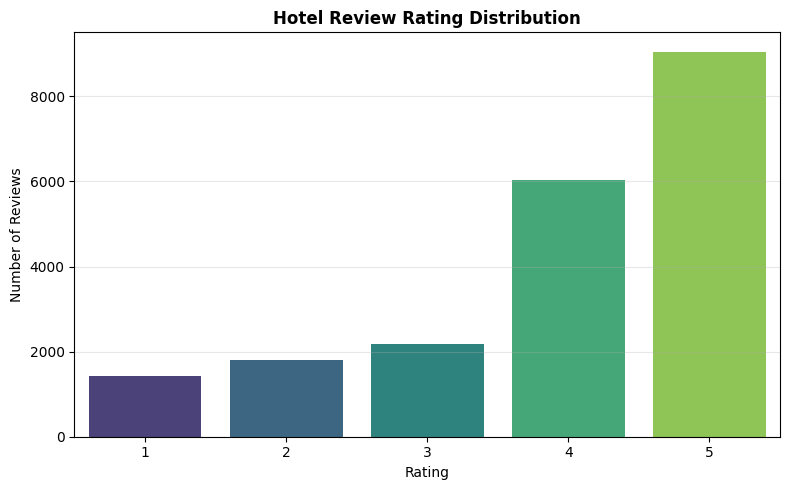

In [4]:
# Rating distribution plot
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x=LABEL_COLUMN, order=sorted(data[LABEL_COLUMN].unique()), palette='viridis')
plt.title('Hotel Review Rating Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Text Cleaning Pipeline

In [5]:
# Text cleaning helper functions
lemmatizer = WordNetLemmatizer()

# Keep negation terms
stop_words = set(stopwords.words('english')) - {'no', 'nor', 'not'}

def expand_contractions(text):
    """Expand common English contractions before removing punctuation."""
    text = re.sub(r"won['’]t", 'will not', text)
    text = re.sub(r"can['’]t", 'can not', text)
    text = re.sub(r"n['’]t", ' not', text)
    text = re.sub(r"['’]re", ' are', text)
    text = re.sub(r"['’]s", ' is', text)
    text = re.sub(r"['’]d", ' would', text)
    text = re.sub(r"['’]ll", ' will', text)
    text = re.sub(r"['’]ve", ' have', text)
    text = re.sub(r"['’]m", ' am', text)
    return text


def clean_text(text):
    """Clean one review and return a lemmatized text string."""
    text = str(text).lower()
    text = expand_contractions(text)

    # Remove URLs, user mentions, hashtags, numbers, and non-letter characters.
    text = re.sub(r'http\S+|www\.\S+|https\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords and lemmatize words to their base verb form.
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word, pos='v') for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [6]:
# Apply cleaning pipeline
data['cleaned_text'] = data[TEXT_COLUMN].apply(clean_text)

sample_view = data[[TEXT_COLUMN, 'cleaned_text', LABEL_COLUMN]].head(5)
sample_view

,Review,cleaned_text,Rating
0,nice hotel expensive parking got good deal sta...,nice hotel expensive park get good deal stay h...,4
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,nice room not experience hotel monaco seattle ...,3
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...,5
4,"great stay great stay, went seahawk game aweso...",great stay great stay go seahawk game awesome ...,5


In [7]:
# Check for empty reviews after cleaning
empty_count = (data['cleaned_text'].str.len() == 0).sum()
print(f'Empty cleaned reviews: {empty_count}')

Empty cleaned reviews: 0


## Cleaned Text Visualization

,word,count
0,not,50724
1,hotel,49885
2,room,47783
3,stay,28556
4,great,21484
5,good,17424
6,staff,16806
7,time,13017
8,nice,12647
9,no,11853


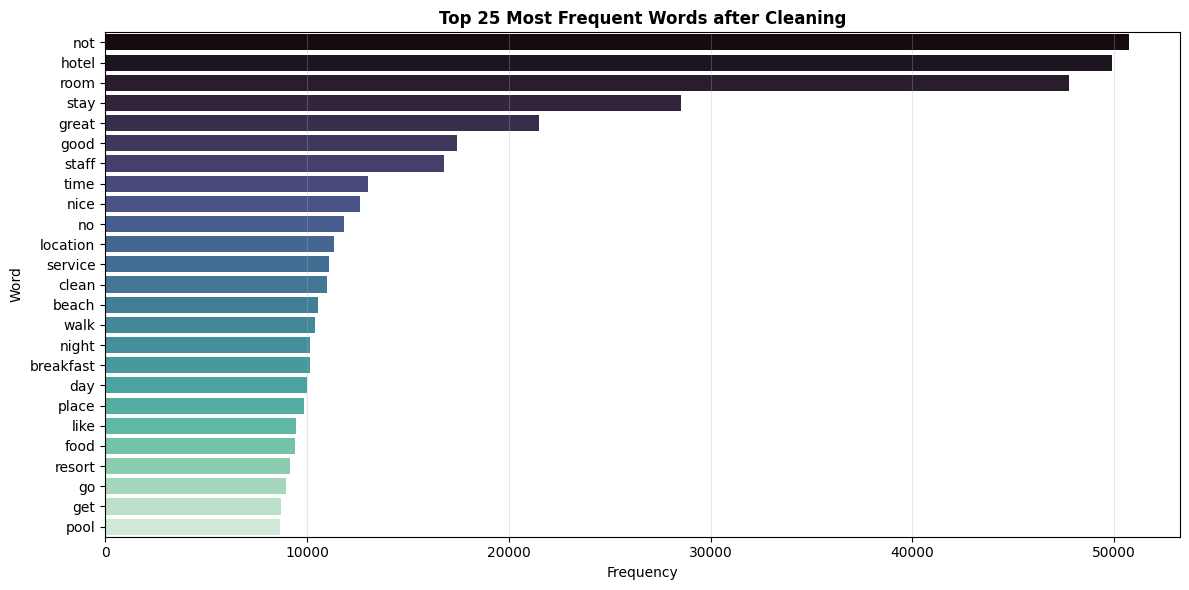

In [8]:
# Most frequent words in cleaned reviews
all_words = ' '.join(data['cleaned_text']).split()
word_counts = Counter(all_words)
top_words = pd.DataFrame(word_counts.most_common(25), columns=['word', 'count'])

display(top_words.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(data=top_words, x='count', y='word', palette='mako')
plt.title('Top 25 Most Frequent Words after Cleaning', fontsize=12, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Train-Test Split, Tokenization and Padding

In [9]:
# Encode labels for 5-class classification
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(data[LABEL_COLUMN])

class_values = list(label_encoder.classes_)
class_names = [f'Rating {rating}' for rating in class_values]
NUM_CLASSES = len(class_values)

print(f'Encoded classes: {dict(zip(class_values, range(NUM_CLASSES)))}')
print(f'Number of classes: {NUM_CLASSES}')

Encoded classes: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4}
Number of classes: 5


In [10]:
# 80/20 train-test split
X_train_text, X_test_text, y_train_full, y_test = train_test_split(
    data['cleaned_text'],
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Preserve original test reviews for later error analysis.
test_original_reviews = data.loc[X_test_text.index, TEXT_COLUMN].reset_index(drop=True)
test_cleaned_reviews = X_test_text.reset_index(drop=True)

print(f'Train text count: {len(X_train_text)}')
print(f'Test text count : {len(X_test_text)}')

Train text count: 16392
Test text count : 4099


In [11]:
# Keras tokenization
MAX_WORDS = 10000
OOV_TOKEN = '<OOV>'

# Fit only on the training text to avoid information leakage.
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print(f'Full tokenizer vocabulary size: {len(tokenizer.word_index) + 1}')
print(f'Vocabulary used by models     : {VOCAB_SIZE}')

Full tokenizer vocabulary size: 37807
Vocabulary used by models     : 10000


In [12]:
# Percentile-based sequence padding
sequence_lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(sequence_lengths, 95))
MAX_LEN = max(MAX_LEN, 1)

X_train_pad_full = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print(f'95th percentile padding length: {MAX_LEN}')
print(f'X_train_pad_full shape       : {X_train_pad_full.shape}')
print(f'X_test_pad shape             : {X_test_pad.shape}')

95th percentile padding length: 265
X_train_pad_full shape       : (16392, 265)
X_test_pad shape             : (4099, 265)


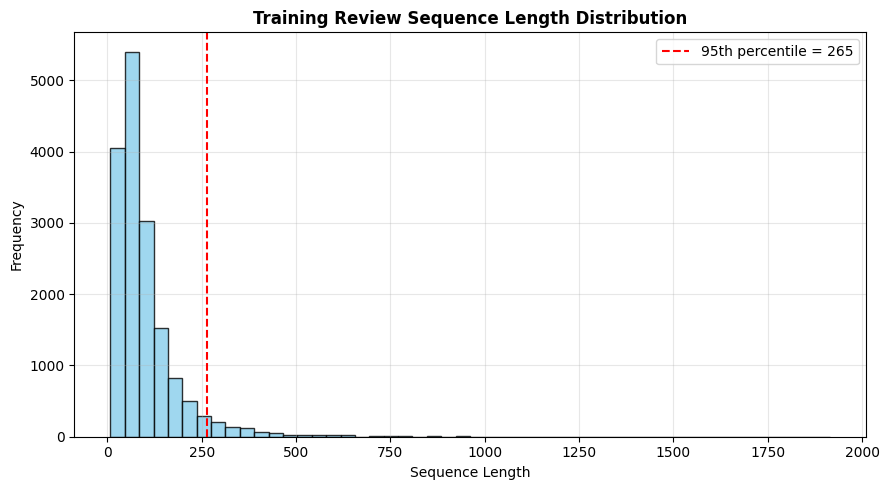

In [13]:
# Sequence length distribution
plt.figure(figsize=(9, 5))
plt.hist(sequence_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'95th percentile = {MAX_LEN}')
plt.title('Training Review Sequence Length Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Validation split from the training set
X_train_pad, X_val_pad, y_train, y_val = train_test_split(
    X_train_pad_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print(f'Model train shape: {X_train_pad.shape}')
print(f'Validation shape : {X_val_pad.shape}')
print(f'Test shape       : {X_test_pad.shape}')

Model train shape: (13113, 265)
Validation shape : (3279, 265)
Test shape       : (4099, 265)


## Helper Functions for Training and Evaluation

In [15]:
# Common training configuration
EPOCHS = 10
BATCH_SIZE = 64
EMBEDDING_DIM = 128
RNN_UNITS = 64

results = []
model_registry = {}
history_registry = {}
predictions_by_model = {}


def get_callbacks(model_name):
    """Return early stopping and checkpoint callbacks for a model."""
    safe_name = model_name.lower().replace(' ', '_').replace('-', '_')
    return [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f'best_{safe_name}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        )
    ]


def plot_history(history, title='', save=None):
    """Plot training and validation loss/accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs_range = range(1, len(history.history['loss']) + 1)

    axes[0].plot(epochs_range, history.history['loss'], 'b-o', ms=3, label='Train')
    axes[0].plot(epochs_range, history.history['val_loss'], 'r-o', ms=3, label='Validation')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history.history['accuracy'], 'b-o', ms=3, label='Train')
    axes[1].plot(epochs_range, history.history['val_accuracy'], 'r-o', ms=3, label='Validation')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


def count_params(model):
    """Count total and trainable model parameters."""
    total_params = model.count_params()
    trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    return total_params, trainable_params


def evaluate_model(model, model_name, training_time):
    """Evaluate a model using accuracy, confusion matrix, and classification report."""
    test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
    y_prob = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    print(f'{model_name} - Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0))

    total_params, trainable_params = count_params(model)
    result = {
        'Model': model_name,
        'Test Loss': test_loss,
        'Test Accuracy': test_acc,
        'Training Time (min)': training_time / 60,
        'Total Params': total_params,
        'Trainable Params': trainable_params
    }
    return result, y_pred


def plot_confusion(y_true, y_pred, title, save=None):
    """Plot a confusion matrix for model predictions."""
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=class_names
    ).plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()

## Model 1: Simple RNN with Trainable Embedding

In [16]:
# Build Simple RNN model
def build_simple_rnn_model():
    model = models.Sequential(name='simple_rnn_trainable_embedding')
    model.add(layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN,
        mask_zero=True,
        name='embedding'
    ))
    model.add(layers.SimpleRNN(RNN_UNITS, name='simple_rnn'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax', name='output'))
    return model

rnn_model = build_simple_rnn_model()
rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
rnn_model.summary()

Model: "simple_rnn_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - accuracy: 0.4385 - loss: 1.3237 - val_accuracy: 0.4825 - val_loss: 1.2137
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.5816 - loss: 1.0705 - val_accuracy: 0.4215 - val_loss: 1.3841
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.7794 - loss: 0.6249 - val_accuracy: 0.4535 - val_loss: 1.4973
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.9294 - loss: 0.2628 - val_accuracy: 0.4361 - val_loss: 1.7379
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


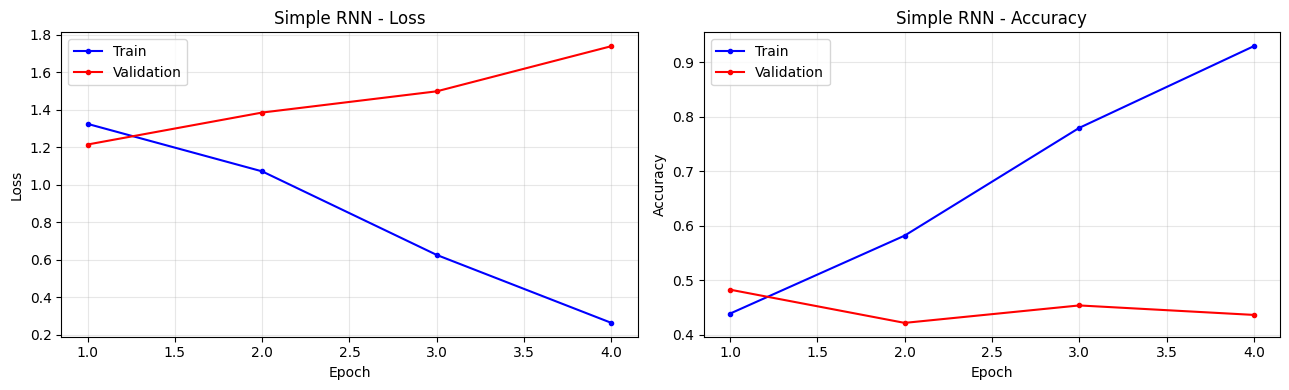

In [17]:
# Train Simple RNN model
t0 = time.time()
history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val),
    callbacks=get_callbacks('Simple RNN'),
    verbose=1
)
rnn_training_time = time.time() - t0

plot_history(history_rnn, 'Simple RNN', 'simple_rnn_curves.png')

Simple RNN - Test Loss: 1.2012 | Test Accuracy: 0.4823

Classification Report:
              precision    recall  f1-score   support

    Rating 1     0.2458    0.8697    0.3832       284
    Rating 2     0.1799    0.0696    0.1004       359
    Rating 3     0.2857    0.0137    0.0262       437
    Rating 4     0.4452    0.0571    0.1012      1208
    Rating 5     0.5865    0.9001    0.7102      1811

    accuracy                         0.4823      4099
   macro avg     0.3486    0.3821    0.2643      4099
weighted avg     0.4536    0.4823    0.3818      4099



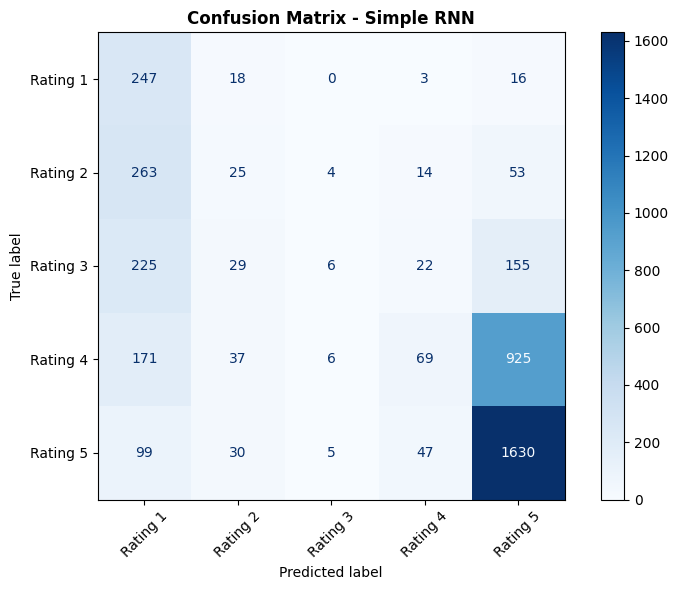

In [18]:
# Evaluate Simple RNN model
rnn_result, y_pred_rnn = evaluate_model(rnn_model, 'Simple RNN', rnn_training_time)
results.append(rnn_result)
model_registry['Simple RNN'] = rnn_model
history_registry['Simple RNN'] = history_rnn
predictions_by_model['Simple RNN'] = y_pred_rnn

plot_confusion(y_test, y_pred_rnn, 'Confusion Matrix - Simple RNN', 'cm_simple_rnn.png')

## Model 2: LSTM with Trainable Embedding

In [19]:

# -- Build LSTM model with trainable embedding -----------------------------
def build_lstm_model():
    model = models.Sequential(name='lstm_trainable_embedding')
    model.add(layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN,
        mask_zero=True,
        name='embedding'
    ))
    model.add(layers.LSTM(RNN_UNITS, name='lstm'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax', name='output'))
    return model

lstm_model = build_lstm_model()
lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "lstm_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 44s 205ms/step - accuracy: 0.5053 - loss: 1.1200 - val_accuracy: 0.5801 - val_loss: 0.9441
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 38s 186ms/step - accuracy: 0.6296 - loss: 0.8390 - val_accuracy: 0.6017 - val_loss: 0.8954
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 38s 184ms/step - accuracy: 0.7078 - loss: 0.6966 - val_accuracy: 0.5794 - val_loss: 0.9754
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 38s 184ms/step - accuracy: 0.7524 - loss: 0.6140 - val_accuracy: 0.5797 - val_loss: 1.0234
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 42s 186ms/step - accuracy: 0.7851 - loss: 0.5403 - val_accuracy: 0.5993 - val_loss: 1.1573
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


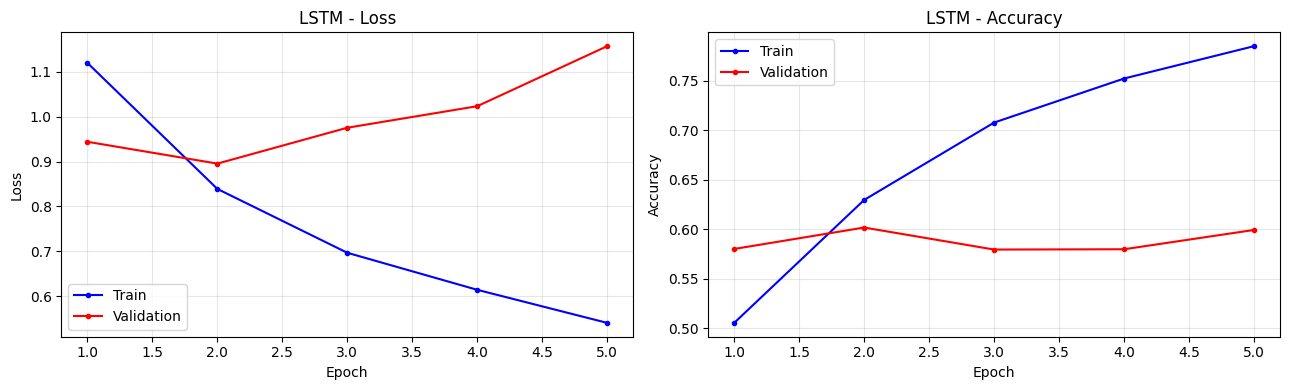

In [20]:
# Train LSTM model
t0 = time.time()
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val),
    callbacks=get_callbacks('LSTM'),
    verbose=1
)
lstm_training_time = time.time() - t0

plot_history(history_lstm, 'LSTM', 'lstm_curves.png')

LSTM - Test Loss: 0.9062 | Test Accuracy: 0.5965

Classification Report:
              precision    recall  f1-score   support

    Rating 1     0.6679    0.6303    0.6486       284
    Rating 2     0.4343    0.4234    0.4288       359
    Rating 3     0.4255    0.2288    0.2976       437
    Rating 4     0.4781    0.6151    0.5380      1208
    Rating 5     0.7512    0.7018    0.7257      1811

    accuracy                         0.5965      4099
   macro avg     0.5514    0.5199    0.5277      4099
weighted avg     0.6025    0.5965    0.5934      4099



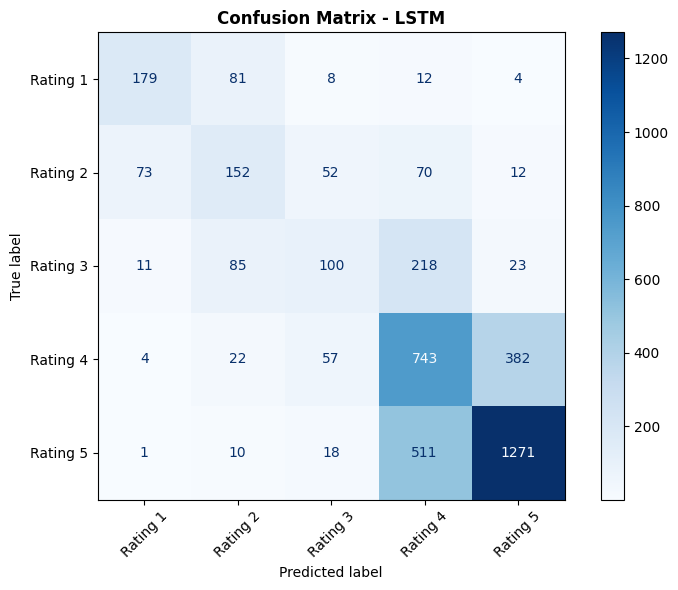

In [21]:
# Evaluate LSTM model
lstm_result, y_pred_lstm = evaluate_model(lstm_model, 'LSTM', lstm_training_time)
results.append(lstm_result)
model_registry['LSTM'] = lstm_model
history_registry['LSTM'] = history_lstm
predictions_by_model['LSTM'] = y_pred_lstm

plot_confusion(y_test, y_pred_lstm, 'Confusion Matrix - LSTM', 'cm_lstm.png')

## LSTM with Pretrained Word2Vec/GloVe Embeddings

In [22]:
# Load pretrained embedding model

try:
    import gensim.downloader as api
except ImportError as exc:
    raise ImportError('Install gensim before running this section: pip install gensim') from exc

PRETRAINED_EMBEDDING_NAME = 'glove-wiki-gigaword-50'
embedding_model = api.load(PRETRAINED_EMBEDDING_NAME)
WORD2VEC_DIM = embedding_model.vector_size

print(f'Loaded pretrained embedding: {PRETRAINED_EMBEDDING_NAME}')
print(f'Embedding dimension: {WORD2VEC_DIM}')

Loaded pretrained embedding: glove-wiki-gigaword-50
Embedding dimension: 50


In [23]:
# Build embedding matrix for tokenizer vocabulary
embedding_matrix = np.zeros((VOCAB_SIZE, WORD2VEC_DIM))
matched_words = 0

for word, index in tokenizer.word_index.items():
    if index >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[index] = embedding_model[word]
        matched_words += 1

coverage = matched_words / max(1, VOCAB_SIZE - 1)
print(f'Matched words: {matched_words:,} / {VOCAB_SIZE - 1:,}')
print(f'Embedding coverage: {coverage:.2%}')

Matched words: 9,459 / 9,999
Embedding coverage: 94.60%


In [24]:
# Build LSTM model with pretrained embedding
def build_lstm_word2vec_model():
    model = models.Sequential(name='lstm_pretrained_word2vec_embedding')
    model.add(layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=WORD2VEC_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        mask_zero=True,
        trainable=False,
        name='pretrained_embedding'
    ))
    model.add(layers.LSTM(RNN_UNITS, name='lstm'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax', name='output'))
    return model

lstm_w2v_model = build_lstm_word2vec_model()
lstm_w2v_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_w2v_model.summary()

Model: "lstm_pretrained_word2vec_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_embedding            │ ?                      │       500,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.4782 - loss: 1.2167 - val_accuracy: 0.5172 - val_loss: 1.0587
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - accuracy: 0.5328 - loss: 1.0557 - val_accuracy: 0.5480 - val_loss: 1.0258
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - accuracy: 0.5588 - loss: 0.9883 - val_accuracy: 0.5715 - val_loss: 0.9649
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - accuracy: 0.5732 - loss: 0.9545 - val_accuracy: 0.5797 - val_loss: 0.9528
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 28s 135ms/step - accuracy: 0.5880 - loss: 0.9222 - val_accuracy: 0.5993 - val_loss: 0.9202
Epoch 6/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.6019 - loss: 0.8941 - val_accuracy: 0.6118 - val_loss: 0.8980
Epoch 7/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.6131 - loss: 0.8706 - val_accuracy: 0.6133 - val_loss: 0.8919
Epoch 8/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.6230 - loss: 0.8545

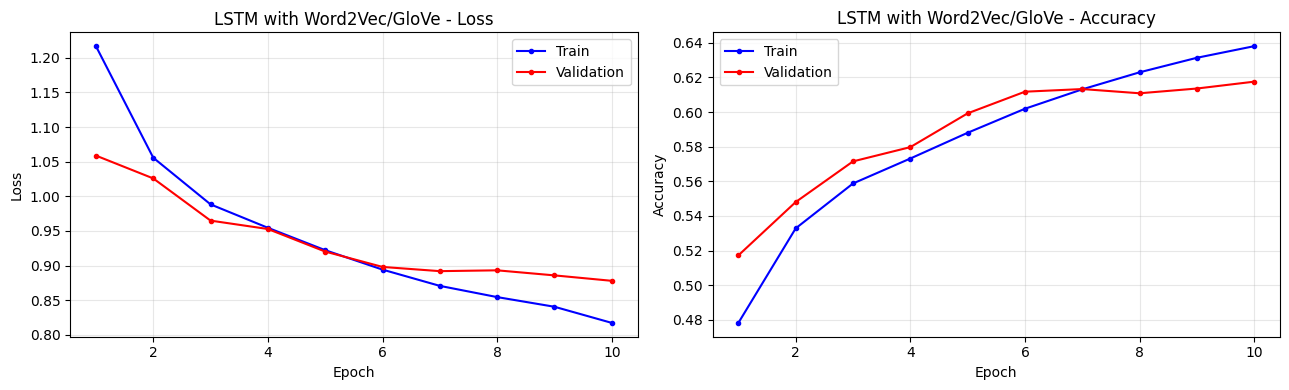

In [25]:
# Train LSTM + pretrained embedding model
t0 = time.time()
history_lstm_w2v = lstm_w2v_model.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val),
    callbacks=get_callbacks('LSTM Word2Vec'),
    verbose=1
)
lstm_w2v_training_time = time.time() - t0

plot_history(history_lstm_w2v, 'LSTM with Word2Vec/GloVe', 'lstm_word2vec_curves.png')

LSTM + Word2Vec - Test Loss: 0.8951 | Test Accuracy: 0.5965

Classification Report:
              precision    recall  f1-score   support

    Rating 1     0.7614    0.4718    0.5826       284
    Rating 2     0.4132    0.4708    0.4401       359
    Rating 3     0.3837    0.2151    0.2757       437
    Rating 4     0.4860    0.5613    0.5209      1208
    Rating 5     0.7311    0.7565    0.7436      1811

    accuracy                         0.5965      4099
   macro avg     0.5551    0.4951    0.5126      4099
weighted avg     0.5961    0.5965    0.5903      4099



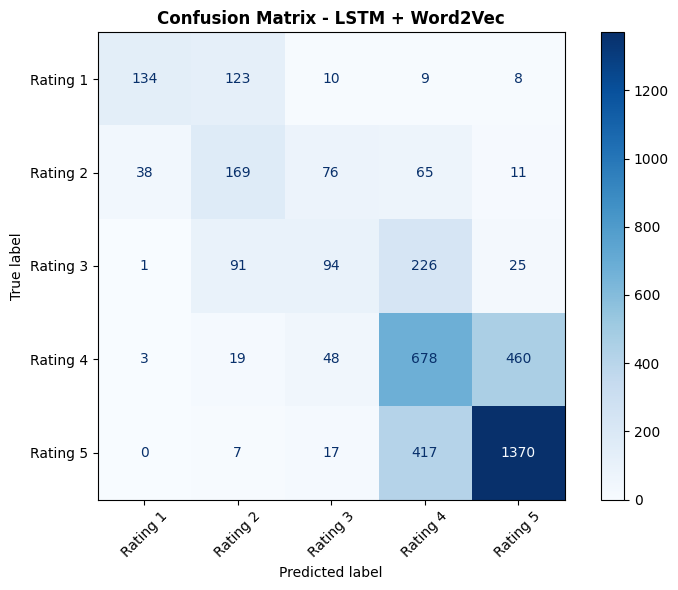

In [26]:
# Evaluate LSTM + pretrained embedding model
lstm_w2v_result, y_pred_lstm_w2v = evaluate_model(
    lstm_w2v_model,
    'LSTM + Word2Vec',
    lstm_w2v_training_time
)
results.append(lstm_w2v_result)
model_registry['LSTM + Word2Vec'] = lstm_w2v_model
history_registry['LSTM + Word2Vec'] = history_lstm_w2v
predictions_by_model['LSTM + Word2Vec'] = y_pred_lstm_w2v

plot_confusion(y_test, y_pred_lstm_w2v, 'Confusion Matrix - LSTM + Word2Vec', 'cm_lstm_word2vec.png')

## Model Comparison

,Model,Test Loss,Test Accuracy,Training Time (min),Total Params,Trainable Params
0,LSTM,0.906180,0.596487,3.325310,1329733,1329733
1,LSTM + Word2Vec,0.895078,0.596487,3.559765,529765,29765
2,Simple RNN,1.201170,0.482313,1.732952,1292677,1292677


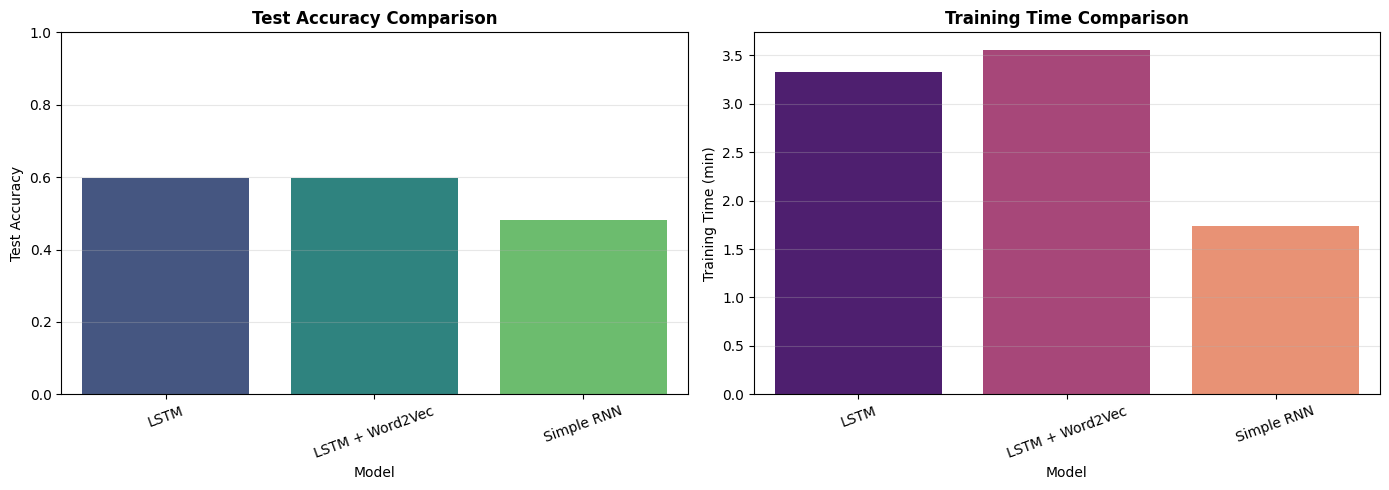

In [27]:
# Compare model performance and complexity
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='Model', y='Test Accuracy', ax=axes[0], palette='viridis')
axes[0].set_title('Test Accuracy Comparison', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(data=results_df, x='Model', y='Training Time (min)', ax=axes[1], palette='magma')
axes[1].set_title('Training Time Comparison', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('language_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Error Analysis

In [28]:
# Select the best model based on test accuracy
best_model_name = results_df.iloc[0]['Model']
best_model = model_registry[best_model_name]
best_predictions = predictions_by_model[best_model_name]

print(f'Best model selected for error analysis: {best_model_name}')

Best model selected for error analysis: LSTM


In [29]:
# Display incorrect predictions
incorrect_positions = np.where(best_predictions != y_test)[0]
print(f'Total incorrect predictions: {len(incorrect_positions)}')

sample_error_positions = incorrect_positions[:3]
error_rows = []

for pos in sample_error_positions:
    true_rating = label_encoder.inverse_transform([y_test[pos]])[0]
    pred_rating = label_encoder.inverse_transform([best_predictions[pos]])[0]
    probs = best_model.predict(X_test_pad[pos:pos+1], verbose=0)[0]
    confidence = float(np.max(probs))

    error_rows.append({
        'Original Review': test_original_reviews.iloc[pos][:400],
        'Cleaned Review': test_cleaned_reviews.iloc[pos][:400],
        'True Rating': true_rating,
        'Predicted Rating': pred_rating,
        'Prediction Confidence': confidence,
        'Cleaned Token Count': len(test_cleaned_reviews.iloc[pos].split())
    })

error_analysis_df = pd.DataFrame(error_rows)
display(error_analysis_df)

Total incorrect predictions: 1654


,Original Review,Cleaned Review,True Rating,Predicted Rating,Prediction Confidence,Cleaned Token Count
0,"great location nice staff mattresses soft, jus...",great location nice staff mattresses soft nigh...,3,4,0.427334,98
1,"nice hotel nice hotel good area explore, arriv...",nice hotel nice hotel good area explore arriva...,3,4,0.439848,77
2,"felt welcome location, location, location, wif...",felt welcome location location location wife s...,5,4,0.491153,75


In [30]:
# Model complexity vs performance table
complexity_columns = [
    'Model',
    'Test Accuracy',
    'Test Loss',
    'Training Time (min)',
    'Total Params',
    'Trainable Params'
]
complexity_df = results_df[complexity_columns].copy()
display(complexity_df)

,Model,Test Accuracy,Test Loss,Training Time (min),Total Params,Trainable Params
0,LSTM,0.596487,0.906180,3.325310,1329733,1329733
1,LSTM + Word2Vec,0.596487,0.895078,3.559765,529765,29765
2,Simple RNN,0.482313,1.201170,1.732952,1292677,1292677


## Save Best Model and Prediction Utility

In [31]:
# Save the best model
best_model.save('best_hotel_review_rating_model.keras')
print(f'Saved best model: {best_model_name} -> best_hotel_review_rating_model.keras')

Saved best model: LSTM -> best_hotel_review_rating_model.keras


In [32]:
# Single-review prediction function
def predict_rating(review_text, model=best_model):
    """Predict a hotel rating from raw review text."""
    cleaned = clean_text(review_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    probabilities = model.predict(padded, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_rating = label_encoder.inverse_transform([predicted_index])[0]
    confidence = float(np.max(probabilities))

    return {
        'cleaned_text': cleaned,
        'predicted_rating': predicted_rating,
        'confidence': confidence,
        'class_probabilities': dict(zip(class_names, probabilities.round(4)))
    }

## GUI for Real-Time Prediction

In [35]:
# Set True for running the GUI
RUN_GUI = True

if RUN_GUI:
    import tkinter as tk
    from tkinter import messagebox

    def predict_rating_gui():
        user_input = entry.get('1.0', tk.END).strip()
        if user_input == '':
            messagebox.showwarning('Input Error', 'Please enter a hotel review for prediction.')
            return

        prediction = predict_rating(user_input)
        result_text = (
            f"Predicted Rating: {prediction['predicted_rating']}\n"
            f"Confidence: {prediction['confidence']:.2%}"
        )
        result_label.config(text=result_text)

    root = tk.Tk()
    root.title('Hotel Review Rating Predictor')
    root.geometry('600x360')

    instruction_label = tk.Label(
        root,
        text='Enter a hotel review to predict its rating:',
        font=('Arial', 13)
    )
    instruction_label.pack(pady=10)

    entry = tk.Text(root, width=70, height=8, font=('Arial', 11))
    entry.pack(pady=10)

    predict_button = tk.Button(
        root,
        text='Predict Rating',
        font=('Arial', 12),
        command=predict_rating_gui
    )
    predict_button.pack(pady=8)

    result_label = tk.Label(root, text='', font=('Arial', 14), fg='blue')
    result_label.pack(pady=10)

    root.mainloop()

## Final Summary Printout

In [34]:
# Final results summary
print('=' * 70)
print('FINAL LANGUAGE TASK RESULTS SUMMARY')
print('=' * 70)
print(results_df.to_string(index=False))
print('=' * 70)
print(f'Best model: {best_model_name}')

FINAL LANGUAGE TASK RESULTS SUMMARY
          Model  Test Loss  Test Accuracy  Training Time (min)  Total Params  Trainable Params
           LSTM   0.906180       0.596487             3.325310       1329733           1329733
LSTM + Word2Vec   0.895078       0.596487             3.559765        529765             29765
     Simple RNN   1.201170       0.482313             1.732952       1292677           1292677
Best model: LSTM
